# 🚢 Titanic Dataset: Exploratory Data Analysis & Logistic Regression From Scratch

This notebook covers a end-to-end Machine Learning pipeline on the Titanic dataset:
1. **Exploratory Data Analysis (EDA)** & Data Visualization
2. **Feature Engineering & Preprocessing** (Imputation, Title extraction, One-Hot Encoding, Scaling)
3. **Logistic Regression Implementation From Scratch** (Vectorized Gradient Descent)
4. **Model Validation & Comparison** against Scikit-Learn's baseline model.

## 1. Imports & Environment Setup
Importing essential libraries for data manipulation, numerical computing, visualization, and validation.

In [1]:
# Necessary Modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities for comparison
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Sklearn necessary training module
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression

## 2. Dataset Loading & Inspection
Inspecting the dataset structure, data types, and initial missing value counts.

In [2]:
# Load datase
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(df.shape, "\n")
print(df.info(), "\n")
print(df.isnull().sum())

(891, 12) 

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB
None 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int6

In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Exploratory Data Analysis (EDA) & Visualizations
Analyzing key relationships between features (`Sex`, `Pclass`, `Age`, `Fare`) and passenger survival rates.

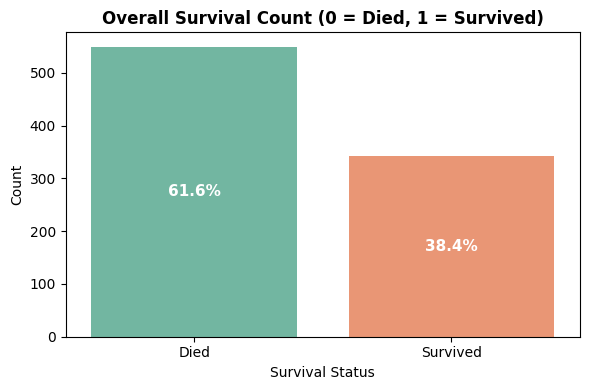

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(data=df, x='Survived', hue='Survived', palette='Set2', legend=False, ax=ax)
ax.set_title('Overall Survival Count (0 = Died, 1 = Survived)', fontsize=12, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Died', 'Survived'])
ax.set_xlabel('Survival Status')
ax.set_ylabel('Count')


total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, 
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=11, color='white', weight='bold')

plt.tight_layout()
plt.show()

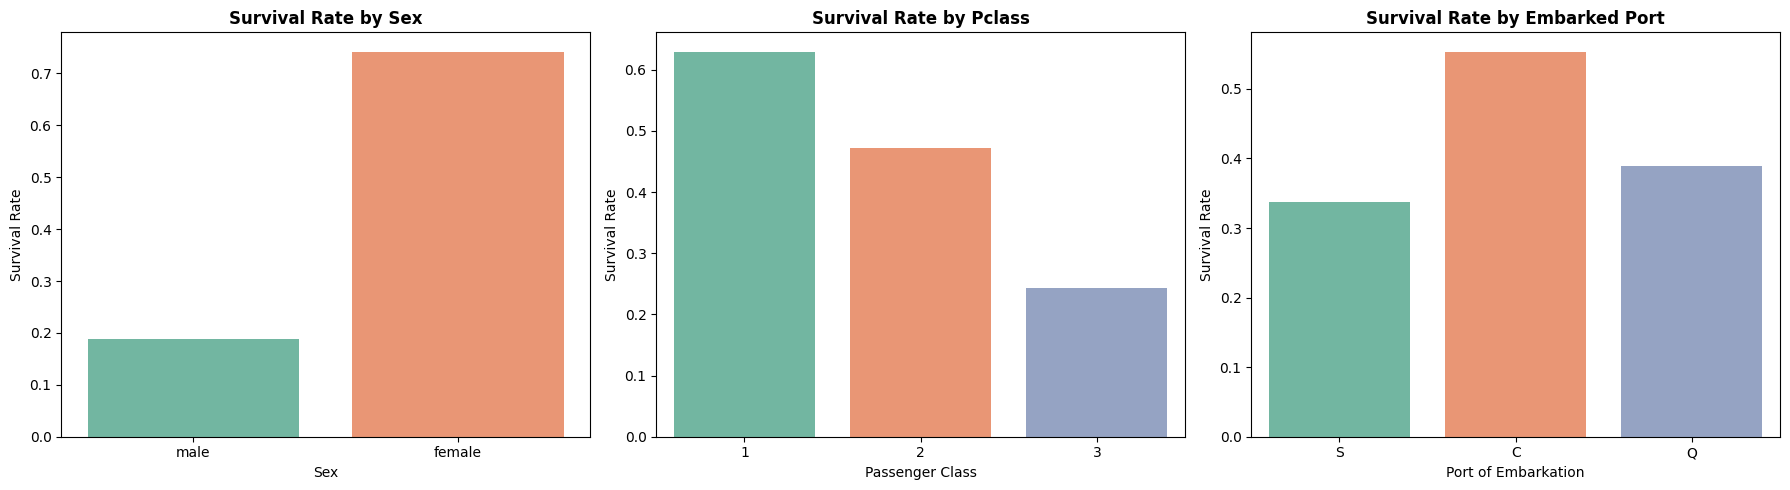

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Survival by Sex
sns.barplot(data=df, x='Sex', y='Survived', hue='Sex', palette='Set2', legend=False, errorbar=None, ax=axes[0])
axes[0].set_title('Survival Rate by Sex', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Survival Rate')
axes[0].set_xlabel('Sex')

# 2. Survival by Pclass
sns.barplot(data=df, x='Pclass', y='Survived', hue='Pclass', palette='Set2', legend=False, errorbar=None, ax=axes[1])
axes[1].set_title('Survival Rate by Pclass', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xlabel('Passenger Class')

# 3. Survival by Embarked
sns.barplot(data=df, x='Embarked', y='Survived', hue='Embarked', palette='Set2', legend=False, errorbar=None, ax=axes[2])
axes[2].set_title('Survival Rate by Embarked Port', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Survival Rate')
axes[2].set_xlabel('Port of Embarkation')

plt.tight_layout()
plt.show()

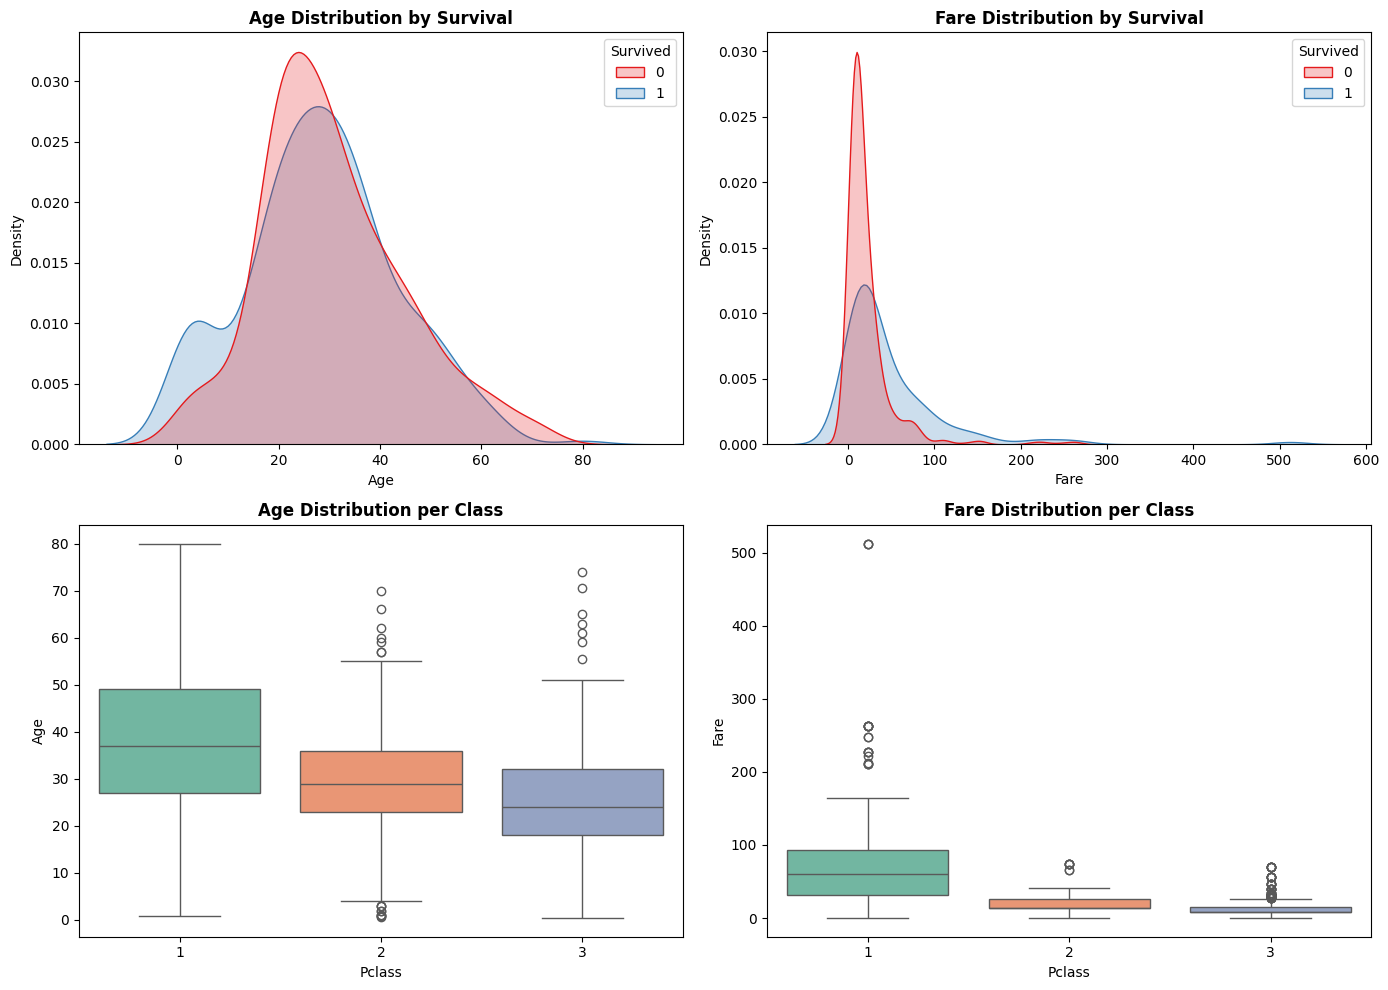

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age Distribution
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True, ax=axes[0, 0], common_norm=False, palette='Set1')
axes[0, 0].set_title('Age Distribution by Survival', fontsize=12, fontweight='bold')

# Fare Distribution
sns.kdeplot(data=df, x='Fare', hue='Survived', fill=True, ax=axes[0, 1], common_norm=False, palette='Set1')
axes[0, 1].set_title('Fare Distribution by Survival', fontsize=12, fontweight='bold')

# Age across Pclass
sns.boxplot(data=df, x='Pclass', y='Age', hue='Pclass', palette='Set2', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Age Distribution per Class', fontsize=12, fontweight='bold')

# Fare across Pclass
sns.boxplot(data=df, x='Pclass', y='Fare', hue='Pclass', palette='Set2', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Fare Distribution per Class', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

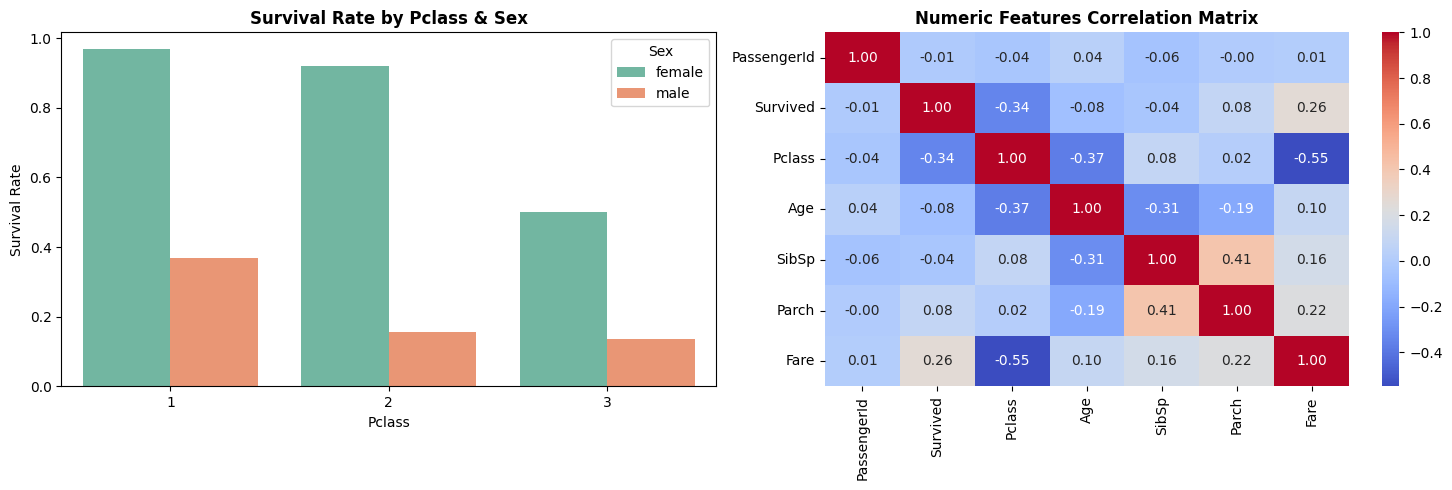

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Interaction: Pclass + Sex vs Survival
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', ax=axes[0], palette='Set2', errorbar=None)
axes[0].set_title('Survival Rate by Pclass & Sex', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Survival Rate')

# Correlation Matrix
num_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1], cbar=True)
axes[1].set_title('Numeric Features Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Feature Engineering & Data Preprocessing
- Extracting passenger titles from `Name` and grouping rare titles.
- Imputing missing `Age` values based on `Title` group medians.
- Creating the `FamilySize` feature (`SibSp` + `Parch` + 1).
- Dropping redundant metadata (`PassengerId`, `Name`, `Ticket`, `Cabin`).
- One-Hot Encoding categorical features and scaling numeric attributes.

In [9]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Group rare title
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# Impute Age using Median grouped by Title
df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

# Impute Embarked with Mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [10]:
# Drop unnecessary metadata columns
df_clean = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'])

# Map binary categorical column
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

# One-hot encode multi-class categorical features
df_clean = pd.get_dummies(df_clean, columns=['Embarked', 'Title'], drop_first=True)



X = df_clean.drop(columns=['Survived']).astype(float).values
y = df_clean['Survived'].values

print("Cleaned DataFrame Columns:\n", df_clean.columns.tolist())
print("Feature matrix shape (X):", X.shape)
print("Target array shape (y):", y.shape)

Cleaned DataFrame Columns:
 ['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']
Feature matrix shape (X): (891, 11)
Target array shape (y): (891,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

X_train_scaled shape: (712, 11)
X_test_scaled shape:  (179, 11)


## 5. Logistic Regression Implementation From Scratch
Implementing binary Logistic Regression using NumPy with vectorized gradient descent optimization.

In [12]:
# Logistic Regression

class LogisticRegressionFromScratch:
    def __init__(self, learning_rate=0.1, n_iter=1000):
        self.bias = None
        self.weights = None
        self.lr = learning_rate
        self.n_iter = n_iter

    def _sigmoid(self, z):
        return(1 / (1 + np.exp(-1*z)))

    def fit(self, X, y):
        m, n = X.shape

        self.bias = 0
        self.weights = np.zeros(n)

        for i in range(self.n_iter):
            z = self.bias + np.dot(X, self.weights)
            y_pred = self._sigmoid(z)

            db = (1/m) * np.sum(y_pred - y)
            dw = (1/m) * np.dot(X.T, (y_pred - y))

            self.bias -= self.lr * db
            self.weights -= self.lr * dw
        
    def get_probabilities(self, X):
        z = self.bias + np.dot(X, self.weights)
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5 ):
        probabilities = self.get_probabilities(X)
        y_pred = probabilities >= threshold
        return y_pred.astype(int)

## 6. Model Training & Scikit-Learn Benchmarking
Training both the scratch implementation and Scikit-Learn's `LogisticRegression` on scaled features to compare test set performance.

In [13]:
# Train Custom Model
custom_model = LogisticRegressionFromScratch(learning_rate=0.1, n_iter=2000)
custom_model.fit(X_train_scaled, y_train)
y_pred_custom = custom_model.predict(X_test_scaled)

# Train Sklearn Model
sklearn_model = SklearnLogisticRegression()
sklearn_model.fit(X_train_scaled, y_train)
y_pred_sklearn = sklearn_model.predict(X_test_scaled)

# Compare Results
acc_custom = accuracy_score(y_test, y_pred_custom)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)


print("             MODEL ACCURACY COMPARISON       ")
print(f"Scratch Model Accuracy : {acc_custom * 100:.2f}%")
print(f"Sklearn Model Accuracy : {acc_sklearn * 100:.2f}%")

print("\n--- Classification Report (Scratch Model) ---")
print(classification_report(y_test, y_pred_custom))

             MODEL ACCURACY COMPARISON       
Scratch Model Accuracy : 81.01%
Sklearn Model Accuracy : 81.01%

--- Classification Report (Scratch Model) ---
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       105
           1       0.77      0.77      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## 7. Model Performance Evaluation
Comparing confusion matrices across both implementations to verify identical classification outputs.

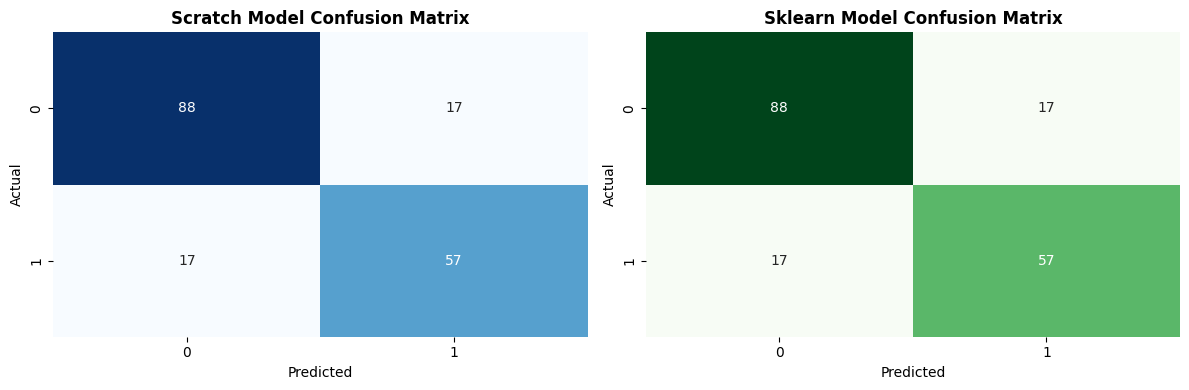

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Custom Model Confusion Matrix
cm_custom = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Scratch Model Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Sklearn Model Confusion Matrix
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Sklearn Model Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()